# 00. Pipeline Demo: Router + Load Balancer

**Theme**: End-to-end demo with **real data** showing Router → Load Balancer → VLM.

This notebook uses:
- Real samples from the PostgreSQL database
- Actual trained Router model predictions  
- Load Balancer scheduling decisions
- Real VLM inference (with try/catch for inactive models)

---
## 1. Setup & Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
import time
import pandas as pd
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
import base64


In [3]:

# Path setup
NOTEBOOK_DIR = Path.cwd()
ROOT_DIR = NOTEBOOK_DIR.parent.parent
ARTEMIS_DIR = ROOT_DIR / 'artemis_final'
CHECKPOINTS_DIR = ARTEMIS_DIR / 'checkpoints'

sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ARTEMIS_DIR))

plt.rcParams['figure.figsize'] = (10, 5)
plt.style.use('seaborn-v0_8-darkgrid')

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"CHECKPOINTS: {CHECKPOINTS_DIR}")

ROOT_DIR: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router
CHECKPOINTS: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints


In [4]:

# Imports
from sqlalchemy import create_engine, text
from artemis_final.load_balancer.public_api import (
    load_capacity_config,
    StatsRegistry,
    ArtemisLoadBalancer,
    RouterOutput,
    SchedulingContext,
    ModelCapacityConfig
)
from artemis_final.ares.configs.db_config import DB_URL, TABLES

DB_AVAILABLE = True # DB_URL is now always available via config


In [5]:
# Load Router (Updated)
import torch
from artemis_final.router.public_api import load_router_from_checkpoint

# Detect device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f"Device: {DEVICE}")

router = None

Device: mps


In [6]:
try:
    # Load Multitask Reward Router
    ckpt_path = CHECKPOINTS_DIR / 'best_multitask_router_v1.pt'
    if not ckpt_path.exists():
        # Fallback path if CHECKPOINTS_DIR is different or file moved
        ckpt_path = ARTEMIS_DIR / 'checkpoints' / 'best_multitask_router_v1.pt'
    
    if ckpt_path.exists():
        router = load_router_from_checkpoint(ckpt_path, router_type="reward", device="cpu")
        print(f" Loaded Reward Router from {ckpt_path.name}")
    else:
        print(f"️ Checkpoint not found at {ckpt_path}")
        
except Exception as e:
    print(f" Failed to load router: {e}")

 Failed to load router: load_router_from_checkpoint() got multiple values for argument 'router_type'


In [7]:


# Helper to ensure compatibility with LB which expects probs
def get_router_probs(decision):
    if 'probs' in decision:
        return decision['probs']
    if 'rewards' in decision:
        # Convert rewards to soft probabilities for LB compatibility
        import numpy as np
        rewards = decision['rewards']
        vals = np.array(list(rewards.values()))
        exp_vals = np.exp(vals - np.max(vals))
        probs_arr = exp_vals / exp_vals.sum()
        return dict(zip(rewards.keys(), probs_arr.tolist()))
    return {}

if router:
    print(f"   Models: {router.model_names}")
    print(f"   Modes: {router.mode_names}")

---
## 2. Load Real Data from Database

In [8]:
def load_samples_with_images(n=5):
    """Load real samples with images from PostgreSQL."""
    if not DB_AVAILABLE:
        print("Database not available, using synthetic samples")
        return [{'sample_id': f'synth_{i}', 'prompt': f'Synthetic prompt {i}', 
                 'router_task': 'vqa', 'image_bytes': None} for i in range(n)]
    
    try:
        engine = create_engine(DB_URL)
        with engine.connect() as conn:
            result = conn.execute(text(f"""
                SELECT s.sample_id, s.prompt_text, s.router_task, s.source_dataset,
                       i.image_bytes, i.img_width, i.img_height
                FROM {TABLES['samples']} s
                LEFT JOIN {TABLES['images']} i ON s.image_id = i.image_id
                WHERE s.prompt_text IS NOT NULL AND i.image_bytes IS NOT NULL
                ORDER BY RANDOM() LIMIT {n}
            """))
            rows = result.fetchall()
        
        samples = []
        for row in rows:
            samples.append({
                'sample_id': row[0],
                'prompt': row[1],
                'router_task': row[2] or 'vqa',
                'source_dataset': row[3],
                'image_bytes': row[4],
                'img_width': row[5],
                'img_height': row[6],
            })
        print(f"Loaded {len(samples)} samples from database")
        return samples
    except Exception as e:
        print(f"Database error: {e}")
        return [{'sample_id': f'fallback_{i}', 'prompt': f'Fallback prompt {i}',
                 'router_task': 'vqa', 'image_bytes': None} for i in range(n)]

In [9]:
# Load samples
samples = load_samples_with_images(5)

print(f"\nLoaded {len(samples)} samples:")
for s in samples:
    img_info = f"{s.get('img_width', '?')}x{s.get('img_height', '?')}" if s.get('image_bytes') else 'None'
    print(f"   {s['sample_id']}: {s['router_task']} | Image: {img_info}")
    print(f"      Prompt: {s['prompt'][:60]}...")

Loaded 5 samples from database

Loaded 5 samples:
   intergps_763_1d999d5b: geometry_reasoning | Image: 411x389
      Prompt: Question: Find x.
Choices:
A. 120
B. 135
C. 145
D. 160
Answe...
   tqa_600_958dc0b8: textbook_qa | Image: 900x792
      Prompt: Question: Which label refers to the bulge?
Choices:
A. k.
B....
   chart2text_109_3d4e4596: chart_captioning | Image: 800x557
      Prompt: Please clarify the meaning conveyed by this graph....
   localized_narratives_322_61b94251: dense_captioning | Image: 680x1024
      Prompt: Can you describe this image briefly?...
   tabmwp_247_739dd2f4: table_math | Image: 287x160
      Prompt: How much more does a designer scarf cost than a designer han...


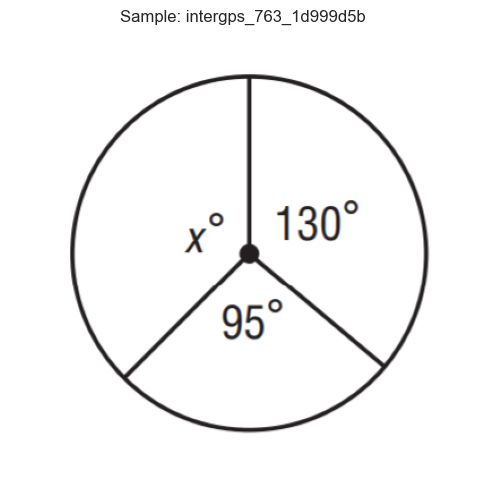

In [10]:
# Display first image
if samples and samples[0].get('image_bytes'):
    img = Image.open(BytesIO(samples[0]['image_bytes']))
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Sample: {samples[0]['sample_id']}")
    plt.axis('off')
    plt.show()
else:
    print("No image available to display")

---
## 3. Load Trained Router

In [18]:
# Load Router (Updated)
import torch
from artemis_final.router.public_api import load_router_from_checkpoint

# Detect device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f"Device: {DEVICE}")

router = None
try:
    # Load Multitask Reward Router
    CHECKPOINTS_DIR = ARTEMIS_DIR / 'checkpoints'
    print(f"CHECKPOINTS_DIR: {CHECKPOINTS_DIR}")
    ckpt_path = CHECKPOINTS_DIR / 'best_multitask_router_v1.pt'
    if not ckpt_path.exists():
        # Fallback path if CHECKPOINTS_DIR is different or file moved
        ckpt_path = ARTEMIS_DIR / 'checkpoints' / 'best_multitask_router_v1.pt'
    print(f"Using checkpoint path: {ckpt_path}")
    if ckpt_path.exists():
        router = load_router_from_checkpoint(checkpoint_path=ckpt_path, router_type="reward", device=DEVICE)
        print(f" Loaded Reward Router from {ckpt_path.name}")
    else:
        print(f"️ Checkpoint not found at {ckpt_path}")
        
except Exception as e:
    print(f" Failed to load router: {e}")

# Helper to ensure compatibility with LB which expects probs
def get_router_probs(decision):
    if 'probs' in decision:
        return decision['probs']
    if 'rewards' in decision:
        # Convert rewards to soft probabilities for LB compatibility
        import numpy as np
        rewards = decision['rewards']
        vals = np.array(list(rewards.values()))
        exp_vals = np.exp(vals - np.max(vals))
        probs_arr = exp_vals / exp_vals.sum()
        return dict(zip(rewards.keys(), probs_arr.tolist()))
    return {}

if router:
    print(f"   Models: {router.model_names}")
    print(f"   Modes: {router.mode_names}")

Device: mps
CHECKPOINTS_DIR: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints
Using checkpoint path: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router_v1.pt
[INFO] Using default RouterModelConfig with hidden_dim=256 (compatible with v1 multitask router)
[INFO] Loading model from: /Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/Which_VLM_Router/artemis_final/checkpoints/best_multitask_router_v1.pt
[INFO] Weights loaded successfully (strict=False).
[INFO] Model loaded on device: mps
[INFO] Text encoder: distilbert-base-uncased
[INFO] Models: ['deepseek_ocr', 'gemma_3_27b', 'qwen2_5_vl_3b', 'qwen2_5_vl_7b', 'qwen3_vl_8b_thinking']
[INFO] Modes: ['accuracy', 'cheap', 'fast', 'balanced']
[INFO] Tasks: 30
 Loaded Reward Router from best_multitask_router_v1.pt
   Models: ['deepseek_ocr', 'gemma_3_2

---
## 4. Initialize Load Balancer

In [19]:
# Load model configs
try:
    model_configs = load_capacity_config()
    print("Loaded model configs:")
    for name, cfg in model_configs.items():
        print(f"   {name}: {cfg.base_latency_ms}ms, ${cfg.cost_per_request_usd:.4f}")
except Exception as e:
    print(f"Using default configs: {e}")
    model_configs = {
        'qwen2_5_vl_7b': ModelCapacityConfig(model_name='qwen2_5_vl_7b', base_latency_ms=800, cost_per_request_usd=0.005),
        'gemma_3_27b': ModelCapacityConfig(model_name='gemma_3_27b', base_latency_ms=2000, cost_per_request_usd=0.01),
    }

Loaded model configs:
   gemma_3_27b: 2000ms, $0.0005
   qwen3_vl_8b_thinking: 1200ms, $0.0030
   qwen2_5_vl_7b: 800ms, $0.0004
   qwen2_5_vl_3b: 400ms, $0.0002
   deepseek_ocr: 300ms, $0.0001


In [20]:
# Create statistics registry
stats = StatsRegistry()

# Create Load Balancer
lb = ArtemisLoadBalancer(
    model_configs=model_configs,
    stats_registry=stats,
    latency_sla_ms={'default': 3000},
    scheduling_mode='capacity_aware',
    simulation_only=False,  # Real mode
)

print("Load Balancer initialized")

Load Balancer initialized


In [ ]:

# === VLM Client Setup ===
from artemis_final.utils.vlm_client_factory import get_vlm_client

# Initialize Client
# simulation_only=False means we try to load real models from config.
# If config is missing or fails, it falls back to Mock.
# Note: In the notebooks below, specific simulation_only flags might override this intention for the Load Balancer,
# but we prepare the client here.
try:
    # Check if 'lb' exists and use its setting, otherwise default to False (Real)
    sim_mode = lb.simulation_only if 'lb' in locals() else False
    vlm_client = get_vlm_client(simulation_only=sim_mode)
    print(f" VLM Client initialized: {type(vlm_client).__name__}")
except Exception as e:
    print(f" Could not initialize VLM client: {e}")
    vlm_client = None


---
## 5. End-to-End Pipeline: Router → Load Balancer → VLM

In [21]:
def run_pipeline(sample, router, lb, mode='balanced', call_vlm=False, client=vlm_client):
    """Run full pipeline for a single sample."""
    result = {'sample_id': sample['sample_id'], 'task': sample['router_task']}
    
    # === STEP 1: Router Prediction ===
    print(f"\n{'='*60}")
    print(f"SAMPLE: {sample['sample_id']} | Task: {sample['router_task']}")
    print(f"{'='*60}")
    print(f"Prompt: {sample['prompt'][:80]}...")
    
    if router:
        try:
            router_result = router.route(
                prompt=sample['prompt'],
                mode=mode,
                metadata={'router_task': sample['router_task']}
            )
            probs = router_result['probs']
            preferred = router_result['chosen_model']
            result['router_time_ms'] = router_result.get('inference_ms', 0)
            
            print(f"\nROUTER (mode={mode}):")
            print(f"   Inference time: {result['router_time_ms']:.1f}ms")
            print(f"   Probabilities:")
            for m, p in sorted(probs.items(), key=lambda x: -x[1]):
                marker = '→' if m == preferred else ' '
                print(f"      {marker} {m}: {p:.1%}")
            print(f"   Chosen: {preferred} ({probs[preferred]:.1%} confidence)")
        except Exception as e:
            print(f"Router error: {e}")
            probs = {list(model_configs.keys())[0]: 1.0}
            preferred = list(model_configs.keys())[0]
    else:
        # Fallback
        probs = {m: 1.0/len(model_configs) for m in model_configs}
        preferred = list(model_configs.keys())[0]
        print("Router not available, using uniform probs")
    
    result['router_choice'] = preferred
    result['confidence'] = probs.get(preferred, 0)
    
    # === STEP 2: Load Balancer ===
    router_output = RouterOutput(
        sample_id=sample['sample_id'],
        task_type=sample['router_task'],
        router_probs=probs,
        preferred_model=preferred,
        max_prob=probs.get(preferred, 0)
    )
    context = SchedulingContext(load_profile='normal', 
        arrival_ts_ms=time.time() * 1000,
        load_profile='production',
    )
    
    decision = lb.schedule(router_output, context)
    
    print(f"\nLOAD BALANCER:")
    print(f"   Router preferred: {decision.preferred_model}")
    print(f"   LB chose: {decision.chosen_model}")
    print(f"   Agreement: {'YES' if decision.chosen_model == decision.preferred_model else 'SWITCHED'}")
    print(f"   Expected latency: {decision.total_latency_ms:.0f}ms")
    print(f"   Queue delay: {decision.queue_delay_ms:.0f}ms")
    print(f"   Est. cost: ${decision.est_cost_usd:.4f}")
    print(f"   SLA violated: {'YES' if decision.sla_violated else 'No'}")
    
    result['lb_choice'] = decision.chosen_model
    result['agreed'] = decision.chosen_model == decision.preferred_model
    result['latency_ms'] = decision.total_latency_ms
    result['cost_usd'] = decision.est_cost_usd
    result['sla_violated'] = decision.sla_violated
    
    # === STEP 3: VLM Inference (optional) ===
    if call_vlm and client and sample.get('image_bytes'):
        print(f"\nVLM INFERENCE ({decision.chosen_model}):")
        try:
            img = Image.open(BytesIO(sample['image_bytes']))
            vlm_result = client.vlm.run_image(
                image=img,
                text=sample['prompt'],
                models=[decision.chosen_model],
                max_tokens=200,
            )
            model_resp = vlm_result.get(decision.chosen_model, {})
            if model_resp.get('ok'):
                print(f"   Actual latency: {model_resp['latency_ms']:.0f}ms")
                print(f"   Response: {model_resp['response_text'][:100]}...")
                result['actual_latency_ms'] = model_resp['latency_ms']
            else:
                print(f"   Error: {model_resp.get('error')}")
        except Exception as e:
            print(f"   VLM call failed: {e}")
    else:
        print(f"\nVLM INFERENCE: Skipped (call_vlm={call_vlm})")
    
    return result

In [22]:
# Run pipeline for each sample
results = []
for sample in samples:
    result = run_pipeline(sample, router, lb, mode='balanced', call_vlm=False)
    results.append(result)


SAMPLE: intergps_763_1d999d5b | Task: geometry_reasoning
Prompt: Question: Find x.
Choices:
A. 120
B. 135
C. 145
D. 160
Answer with the letter....
Router error: 'probs'

LOAD BALANCER:
   Router preferred: gemma_3_27b
   LB chose: gemma_3_27b
   Agreement: YES
   Expected latency: 16368ms
   Queue delay: 0ms
   Est. cost: $0.0001
   SLA violated: YES

VLM INFERENCE: Skipped (call_vlm=False)

SAMPLE: tqa_600_958dc0b8 | Task: textbook_qa
Prompt: Question: Which label refers to the bulge?
Choices:
A. k.
B. n.
C. r.
D. v.
Answ...
Router error: 'probs'

LOAD BALANCER:
   Router preferred: gemma_3_27b
   LB chose: gemma_3_27b
   Agreement: YES
   Expected latency: 1190ms
   Queue delay: 0ms
   Est. cost: $0.0000
   SLA violated: No

VLM INFERENCE: Skipped (call_vlm=False)

SAMPLE: chart2text_109_3d4e4596 | Task: chart_captioning
Prompt: Please clarify the meaning conveyed by this graph....
Router error: 'probs'

LOAD BALANCER:
   Router preferred: gemma_3_27b
   LB chose: gemma_3_27b
   Agr

---
## 6. Results Summary

In [23]:
df = pd.DataFrame(results)
print("\nPipeline Results:")
display(df[['sample_id', 'task', 'router_choice', 'lb_choice', 'agreed', 'latency_ms', 'cost_usd']])

print(f"\nSummary:")
print(f"   Router-LB Agreement: {df['agreed'].mean():.0%}")
print(f"   Avg Latency: {df['latency_ms'].mean():.0f}ms")
print(f"   Total Cost: ${df['cost_usd'].sum():.4f}")
print(f"   SLA Violations: {df['sla_violated'].sum()} / {len(df)}")


Pipeline Results:


,sample_id,task,router_choice,lb_choice,agreed,latency_ms,cost_usd
0,intergps_763_1d999d5b,geometry_reasoning,gemma_3_27b,gemma_3_27b,True,16368.042417,0.000128
1,tqa_600_958dc0b8,textbook_qa,gemma_3_27b,gemma_3_27b,True,1189.850503,0.000030
2,chart2text_109_3d4e4596,chart_captioning,gemma_3_27b,gemma_3_27b,True,9263.379318,0.000073
3,localized_narratives_322_61b94251,dense_captioning,gemma_3_27b,gemma_3_27b,True,11902.170193,0.000039
4,tabmwp_247_739dd2f4,table_math,gemma_3_27b,gemma_3_27b,True,16440.763661,0.000100



Summary:
   Router-LB Agreement: 100%
   Avg Latency: 11033ms
   Total Cost: $0.0004
   SLA Violations: 4 / 5


---
## Summary

This notebook demonstrated the **end-to-end pipeline**:
1. **Load real samples** from PostgreSQL with images
2. **Router** predicts best VLM based on prompt and mode
3. **Load Balancer** validates and schedules, may switch models
4. **VLM** executes inference (optional)

The next notebooks explore specific LB behaviors in detail.